In [11]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing

## Load Data

In [12]:
df = pd.read_csv('results.csv')

In [13]:
df.columns

Index(['p1Name', 'p1Tag', 'p1Lane', 'p1KDA', 'p1KP', 'p1GPM', 'p1Vision',
       'p1WinRate', 'p2Name', 'p2Tag', 'p2Lane', 'p2KDA', 'p2KP', 'p2GPM',
       'p2Vision', 'p2WinRate', 'totalWinRate'],
      dtype='object')

In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

# 1. 데이터 불러오기
df = pd.read_csv("results.csv")

# 2. 절댓값 기반 파생 변수 생성
df['KDA_diff'] = abs(df['p1KDA'] - df['p2KDA'])
df['KP_diff'] = abs(df['p1KP'] - df['p2KP'])
df['WinRate_diff'] = abs(df['p1WinRate'] - df['p2WinRate'])

# 3. Lane 조합 만들기 (순서 무관)
df['Lane_combo'] = df.apply(lambda row: f"{min(row['p1Lane'], row['p2Lane'])}_{max(row['p1Lane'], row['p2Lane'])}", axis=1)
df = pd.get_dummies(df, columns=['Lane_combo'], prefix='Lane_combo')

# 4. Lane 관련 GPM, Vision Feature 확장
lane_combos = [c.replace('Lane_combo_', '') for c in df.columns if c.startswith('Lane_combo_')]

# 파생 변수 생성할 컬럼들을 한 번에 만들어서 추가
new_columns = {}

for lane_combo in lane_combos:
    lane_col = f'Lane_combo_{lane_combo}'
    
    # p1, p2 각각
    new_columns[f'p1GPM_Lane_{lane_combo}'] = df['p1GPM'] * df[lane_col]
    new_columns[f'p2GPM_Lane_{lane_combo}'] = df['p2GPM'] * df[lane_col]
    new_columns[f'p1Vision_Lane_{lane_combo}'] = df['p1Vision'] * df[lane_col]
    new_columns[f'p2Vision_Lane_{lane_combo}'] = df['p2Vision'] * df[lane_col]
    
    # 합
    new_columns[f'GPM_sum_Lane_{lane_combo}'] = (df['p1GPM'] + df['p2GPM']) * df[lane_col]
    new_columns[f'Vision_sum_Lane_{lane_combo}'] = (df['p1Vision'] + df['p2Vision']) * df[lane_col]
    
    # 차
    new_columns[f'GPM_diff_Lane_{lane_combo}'] = abs(df['p1GPM'] - df['p2GPM']) * df[lane_col]
    new_columns[f'Vision_diff_Lane_{lane_combo}'] = abs(df['p1Vision'] - df['p2Vision']) * df[lane_col]

# 한 번에 추가
df = pd.concat([df, pd.DataFrame(new_columns)], axis=1)

# 5. 문자열 컬럼 제거
drop_cols = ['p1Name', 'p1Tag', 'p2Name', 'p2Tag', 'p1Lane', 'p2Lane']
df = df.drop(columns=drop_cols)

# 6. 원래 GPM, Vision 컬럼도 삭제 (이미 확장했으니까)
df = df.drop(columns=['p1GPM', 'p2GPM', 'p1Vision', 'p2Vision'])

# 7. 특성과 타겟 분리
X = df.drop(columns=['totalWinRate'])
y = df['totalWinRate']

# 8. 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 9. 스케일링 준비
# (1) 절댓값 기반 파생 변수 → StandardScaler
standard_scaler_cols = ['KDA_diff', 'KP_diff', 'WinRate_diff']

# (2) Lane 조합 (one-hot) → 따로 스케일링 X (0,1이니까)

# (3) GPM, Vision 관련 Feature → RobustScaler
robust_scaler_cols = [col for col in X.columns if 
                      ('GPM' in col or 'Vision' in col) and not col in standard_scaler_cols]

# (4) totalWinRate (y값) → MinMaxScaler
minmax_scaler = MinMaxScaler()
y_train = minmax_scaler.fit_transform(y_train.values.reshape(-1, 1)).ravel()
y_test = minmax_scaler.transform(y_test.values.reshape(-1, 1)).ravel()

# 10. 실제 스케일링 적용
standard_scaler = StandardScaler()
robust_scaler = RobustScaler()

X_train[standard_scaler_cols] = standard_scaler.fit_transform(X_train[standard_scaler_cols])
X_test[standard_scaler_cols] = standard_scaler.transform(X_test[standard_scaler_cols])

X_train[robust_scaler_cols] = robust_scaler.fit_transform(X_train[robust_scaler_cols])
X_test[robust_scaler_cols] = robust_scaler.transform(X_test[robust_scaler_cols])

print("✅ 데이터 전처리 완료!")

✅ 데이터 전처리 완료!


In [23]:
import pandas as pd

# 모든 컬럼과 행을 출력할 수 있도록 설정
pd.set_option('display.max_columns', None)  # 컬럼 수 제한 없앰
pd.set_option('display.max_rows', None)     # 행 수 제한 없앰
pd.set_option('display.width', None)        # 출력 너비 자동 설정
pd.set_option('display.max_colwidth', None) # 각 컬럼의 최대 너비 제한 없앰

X.loc[0]

p1KDA                      6.88
p1KP                      58.14
p1WinRate                 43.33
p2KDA                      4.85
p2KP                      49.43
p2WinRate                 49.08
KDA_diff                   2.03
KP_diff                    8.71
WinRate_diff               5.75
Lane_combo_-1_0           False
Lane_combo_-1_1           False
Lane_combo_-1_2           False
Lane_combo_-1_4           False
Lane_combo_0_0            False
Lane_combo_0_1            False
Lane_combo_0_2            False
Lane_combo_0_3            False
Lane_combo_0_4            False
Lane_combo_1_1            False
Lane_combo_1_2            False
Lane_combo_1_3            False
Lane_combo_1_4            False
Lane_combo_2_2            False
Lane_combo_2_3            False
Lane_combo_2_4             True
Lane_combo_3_3            False
Lane_combo_3_4            False
Lane_combo_4_4            False
p1GPM_Lane_-1_0             0.0
p2GPM_Lane_-1_0             0.0
p1Vision_Lane_-1_0          0.0
p2Vision

In [25]:
# 기본 설정으로 되돌리기
pd.reset_option('display.max_columns')
pd.reset_option('display.max_rows')
pd.reset_option('display.width')
pd.reset_option('display.max_colwidth')

# Model Comparison

## Lasso

In [33]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 데이터 준비 (X, y가 이미 준비되어 있다고 가정)
# X, y를 훈련 세트와 테스트 세트로 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 파이프라인을 이용해 Lasso 회귀와 스케일링을 동시에 적용
lasso = Lasso(max_iter=100000, tol=1e-4)  # max_iter를 크게 늘리고, tol 값을 작게 설정하여 수렴을 더 정확하게 유도
pipeline = make_pipeline(StandardScaler(), lasso)

# 파라미터 튜닝을 위한 그리드 서치 설정
param_grid = {'lasso__alpha': [0.018, 0.019, 0.02, 0.021, 0.022]}  # alpha 값 범위

# 그리드 서치를 통한 최적 alpha 값 찾기
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# 최적의 alpha와 해당 성능 출력
print(f"최적 alpha: {grid_search.best_params_['lasso__alpha']}")
print(f"교차 검증 평균 MSE: {-grid_search.best_score_}")

# 최적 모델 평가
best_model = grid_search.best_estimator_
train_mse = mean_squared_error(y_train, best_model.predict(X_train))
test_mse = mean_squared_error(y_test, best_model.predict(X_test))
train_r2 = best_model.score(X_train, y_train)
test_r2 = best_model.score(X_test, y_test)

print(f"훈련 세트 MSE: {train_mse}")
print(f"테스트 세트 MSE: {test_mse}")
print(f"훈련 세트 R²: {train_r2}")
print(f"테스트 세트 R²: {test_r2}")

최적 alpha: 0.021
교차 검증 평균 MSE: 169.3528828095224
훈련 세트 MSE: 157.56268731244847
테스트 세트 MSE: 168.3266437110652
훈련 세트 R²: 0.20568186827190926
테스트 세트 R²: 0.15506902252424115


## ElasticNet

In [37]:
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 데이터 준비 (X, y가 이미 준비되어 있다고 가정)
# X, y를 훈련 세트와 테스트 세트로 분할
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ElasticNet 모델 정의 (alpha와 l1_ratio 튜닝)
elasticnet = ElasticNet(max_iter=1000000, tol=1e-5)  # max_iter를 크게 늘리고, tol 값을 작게 설정하여 수렴을 유도
pipeline = make_pipeline(StandardScaler(), elasticnet)

# 파라미터 튜닝을 위한 그리드 서치 설정
param_grid = {
    'elasticnet__alpha': [0.018, 0.019, 0.01, 0.011, 0.012],  # alpha 값 범위
    'elasticnet__l1_ratio': [0.92, 0.94, 0.96, 0.98, 1.0]  # Lasso와 Ridge의 혼합 비율
}

# 그리드 서치를 통한 최적 alpha와 l1_ratio 값 찾기
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# 최적의 alpha와 l1_ratio 값 출력
print(f"최적 alpha: {grid_search.best_params_['elasticnet__alpha']}")
print(f"최적 l1_ratio: {grid_search.best_params_['elasticnet__l1_ratio']}")
print(f"교차 검증 평균 MSE: {-grid_search.best_score_}")

# 최적 모델 평가
best_model = grid_search.best_estimator_
train_mse = mean_squared_error(y_train, best_model.predict(X_train))
test_mse = mean_squared_error(y_test, best_model.predict(X_test))
train_r2 = best_model.score(X_train, y_train)
test_r2 = best_model.score(X_test, y_test)

print(f"훈련 세트 MSE: {train_mse}")
print(f"테스트 세트 MSE: {test_mse}")
print(f"훈련 세트 R²: {train_r2}")
print(f"테스트 세트 R²: {test_r2}")

최적 alpha: 0.019
최적 l1_ratio: 0.98
교차 검증 평균 MSE: 168.99948018834908
훈련 세트 MSE: 157.1780740802611
테스트 세트 MSE: 166.61266593969603
훈련 세트 R²: 0.20762081250572517
테스트 세트 R²: 0.16367249064911227


## Ridge

In [47]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 데이터 준비 (X, y가 이미 준비되어 있다고 가정)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Ridge 모델 정의
ridge = Ridge()

# 파이프라인 생성: StandardScaler를 사용하여 데이터를 스케일링 후 Ridge 모델 적용
pipeline = make_pipeline(StandardScaler(), ridge)

# 파라미터 튜닝을 위한 그리드 서치 설정
param_grid = {
    'ridge__alpha': [15.2, 15.3, 15.4, 15.5, 15.6, 15.7]  # alpha 값 범위
}

# 그리드 서치를 통한 최적 alpha 값 찾기
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# 최적의 alpha 값 출력
print(f"최적 alpha: {grid_search.best_params_['ridge__alpha']}")
print(f"교차 검증 평균 MSE: {-grid_search.best_score_}")

# 최적 모델 평가
best_model = grid_search.best_estimator_
train_mse = mean_squared_error(y_train, best_model.predict(X_train))
test_mse = mean_squared_error(y_test, best_model.predict(X_test))
train_r2 = best_model.score(X_train, y_train)
test_r2 = best_model.score(X_test, y_test)

print(f"훈련 세트 MSE: {train_mse}")
print(f"테스트 세트 MSE: {test_mse}")
print(f"훈련 세트 R²: {train_r2}")
print(f"테스트 세트 R²: {test_r2}")

최적 alpha: 15.6
교차 검증 평균 MSE: 169.53929773733614
훈련 세트 MSE: 155.4151528847044
테스트 세트 MSE: 165.21847810083892
훈련 세트 R²: 0.21650819754798178
테스트 세트 R²: 0.17067074397074555


## SVR

### kernel = linear

In [49]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 데이터 준비 (X, y가 이미 준비되어 있다고 가정)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVR 모델 정의 (선형 커널 사용)
svr = SVR(kernel='linear')

# 파이프라인 생성: StandardScaler로 데이터 스케일링 후 SVR 모델 적용
pipeline = make_pipeline(StandardScaler(), svr)

# 파라미터 튜닝을 위한 그리드 서치 설정
param_grid = {
    'svr__C': [0.8, 0.9, 1, 1.2, 1.3],  # C 값 범위
    'svr__epsilon': [0.09, 0.08, 0.1, 0.11, 0.12]  # epsilon 값 범위
}

# 그리드 서치를 통한 최적 C, epsilon 값 찾기
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# 최적의 C, epsilon 값 출력
print(f"최적 C: {grid_search.best_params_['svr__C']}")
print(f"최적 epsilon: {grid_search.best_params_['svr__epsilon']}")
print(f"교차 검증 평균 MSE: {-grid_search.best_score_}")

# 최적 모델 평가
best_model = grid_search.best_estimator_
train_mse = mean_squared_error(y_train, best_model.predict(X_train))
test_mse = mean_squared_error(y_test, best_model.predict(X_test))
train_r2 = best_model.score(X_train, y_train)
test_r2 = best_model.score(X_test, y_test)

print(f"훈련 세트 MSE: {train_mse}")
print(f"테스트 세트 MSE: {test_mse}")
print(f"훈련 세트 R²: {train_r2}")
print(f"테스트 세트 R²: {test_r2}")

최적 C: 1
최적 epsilon: 0.11
교차 검증 평균 MSE: 172.39887321266613
훈련 세트 MSE: 157.36050959425492
테스트 세트 MSE: 165.87412225981618
훈련 세트 R²: 0.2067011034102012
테스트 세트 R²: 0.16737967817208432


### kernel = rbf

In [53]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import mean_squared_error

# 데이터 준비 (X, y가 이미 준비되어 있다고 가정)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# SVR 모델 정의 (RBF 커널 사용)
svr = SVR(kernel='rbf')

# 파이프라인 생성: StandardScaler로 데이터 스케일링 후 SVR 모델 적용
pipeline = make_pipeline(StandardScaler(), svr)

# 파라미터 튜닝을 위한 그리드 서치 설정
param_grid = {
    'svr__C': [8, 9, 10, 11, 12],  # C 값 범위
    'svr__epsilon': [0.4, 0.5],  # epsilon 값 범위
    'svr__gamma': ['auto']  # gamma 값 범위
}

# 그리드 서치를 통한 최적 C, epsilon, gamma 값 찾기
grid_search = GridSearchCV(pipeline, param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train, y_train)

# 최적의 C, epsilon, gamma 값 출력
print(f"최적 C: {grid_search.best_params_['svr__C']}")
print(f"최적 epsilon: {grid_search.best_params_['svr__epsilon']}")
print(f"최적 gamma: {grid_search.best_params_['svr__gamma']}")
print(f"교차 검증 평균 MSE: {-grid_search.best_score_}")

# 최적 모델 평가
best_model = grid_search.best_estimator_
train_mse = mean_squared_error(y_train, best_model.predict(X_train))
test_mse = mean_squared_error(y_test, best_model.predict(X_test))
train_r2 = best_model.score(X_train, y_train)
test_r2 = best_model.score(X_test, y_test)

print(f"훈련 세트 MSE: {train_mse}")
print(f"테스트 세트 MSE: {test_mse}")
print(f"훈련 세트 R²: {train_r2}")
print(f"테스트 세트 R²: {test_r2}")

최적 C: 12
최적 epsilon: 0.5
최적 gamma: auto
교차 검증 평균 MSE: 173.43273290695566
훈련 세트 MSE: 155.7927430461211
테스트 세트 MSE: 171.8730587841526
훈련 세트 R²: 0.21460465860299893
테스트 세트 R²: 0.13726746783167587


## Ensenble

### RandomForestRegressor

In [6]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, r2_score

# 기본 모델
rf = RandomForestRegressor(random_state=42)

# 하이퍼파라미터 그리드
param_grid = {
    'n_estimators': [175, 180, 185],
    'max_depth': [7],
    'min_samples_split': [4],
    'min_samples_leaf': [4],
    'max_features': ['sqrt', 'log2', None]  # ✅ 'auto' 제거하고 None 추가
}

# GridSearchCV로 튜닝
grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

# 학습
grid_search.fit(X_train, y_train)

# 최적 모델
best_rf = grid_search.best_estimator_

# 최적 파라미터 출력
print(f"✅ 최적 파라미터: {grid_search.best_params_}")

# 평가
y_train_pred = best_rf.predict(X_train)
y_test_pred = best_rf.predict(X_test)

print("✅ RandomForestRegressor 최적 파라미터:", grid_search.best_params_)
print(f"훈련 세트 MSE: {mean_squared_error(y_train, y_train_pred)}")
print(f"테스트 세트 MSE: {mean_squared_error(y_test, y_test_pred)}")
print(f"훈련 세트 R²: {r2_score(y_train, y_train_pred)}")
print(f"테스트 세트 R²: {r2_score(y_test, y_test_pred)}")


Fitting 5 folds for each of 9 candidates, totalling 45 fits
✅ 최적 파라미터: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 185}
✅ RandomForestRegressor 최적 파라미터: {'max_depth': 7, 'max_features': None, 'min_samples_leaf': 4, 'min_samples_split': 4, 'n_estimators': 185}
훈련 세트 MSE: 0.014141736531208069
테스트 세트 MSE: 0.017120755233117377
훈련 세트 R²: 0.28707500916223583
테스트 세트 R²: 0.14060803831674418


### Gradient Boosting Regressor

In [7]:
from sklearn.ensemble import GradientBoostingRegressor

# 그라디언트 부스팅 그리드 탐색
gb_param_grid = {
    'n_estimators': [120, 130],
    'learning_rate': [0.13],
    'max_depth': [2],
    'min_samples_split': [4],
    'min_samples_leaf': [1]
}

gb = GradientBoostingRegressor(random_state=42)
gb_grid = GridSearchCV(gb, gb_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
gb_grid.fit(X_train, y_train)

print("✅ GradientBoosting 최적 파라미터:", gb_grid.best_params_)
print(f"훈련 세트 MSE: {mean_squared_error(y_train, y_train_pred)}")
print(f"테스트 세트 MSE: {mean_squared_error(y_test, y_test_pred)}")
print("훈련 세트 R²:", gb_grid.best_estimator_.score(X_train, y_train))
print("테스트 세트 R²:", gb_grid.best_estimator_.score(X_test, y_test))

Fitting 5 folds for each of 2 candidates, totalling 10 fits
✅ GradientBoosting 최적 파라미터: {'learning_rate': 0.13, 'max_depth': 2, 'min_samples_leaf': 1, 'min_samples_split': 4, 'n_estimators': 120}
훈련 세트 MSE: 0.014141736531208069
테스트 세트 MSE: 0.017120755233117377
훈련 세트 R²: 0.27029409612529365
테스트 세트 R²: 0.15053139971325757


### XGBoost Regressor

In [8]:
from xgboost import XGBRegressor

# XGBoost 그리드 탐색
xgb_param_grid = {
    'n_estimators': [160, 170, 180],
    'learning_rate': [0.08],
    'max_depth': [2],
    'subsample': [0.7],
    'colsample_bytree': [0.8]
}

xgb = XGBRegressor(random_state=42, verbosity=0)
xgb_grid = GridSearchCV(xgb, xgb_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
xgb_grid.fit(X_train, y_train)

print("✅ XGBoost 최적 파라미터:", xgb_grid.best_params_)
print(f"훈련 세트 MSE: {mean_squared_error(y_train, y_train_pred)}")
print(f"테스트 세트 MSE: {mean_squared_error(y_test, y_test_pred)}")
print("훈련 세트 R²:", xgb_grid.best_estimator_.score(X_train, y_train))
print("테스트 세트 R²:", xgb_grid.best_estimator_.score(X_test, y_test))


Fitting 5 folds for each of 3 candidates, totalling 15 fits
✅ XGBoost 최적 파라미터: {'colsample_bytree': 0.8, 'learning_rate': 0.08, 'max_depth': 2, 'n_estimators': 170, 'subsample': 0.7}
훈련 세트 MSE: 0.014141736531208069
테스트 세트 MSE: 0.017120755233117377
훈련 세트 R²: 0.26272833003163865
테스트 세트 R²: 0.16768264614318895


### LightGBM Regressor
너무 오래 걸림(발산)

In [9]:
from lightgbm import LGBMRegressor

# LightGBM 그리드 탐색
lgb_param_grid = {
    'n_estimators': [80, 100, 120],
    'learning_rate': [0.08, 0.1, 0.12],
    'max_depth': [1, 2 ,3],
    'num_leaves': [16, 20, 24],
    'subsample': [0.6, 0.8, 1]
}

lgb = LGBMRegressor(random_state=42)
lgb_grid = GridSearchCV(lgb, lgb_param_grid, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
lgb_grid.fit(X_train, y_train)

print("✅ LightGBM 최적 파라미터:", lgb_grid.best_params_)
print(f"훈련 세트 MSE: {mean_squared_error(y_train, y_train_pred)}")
print(f"테스트 세트 MSE: {mean_squared_error(y_test, y_test_pred)}")
print("훈련 세트 R²:", lgb_grid.best_estimator_.score(X_train, y_train))
print("테스트 세트 R²:", lgb_grid.best_estimator_.score(X_test, y_test))


Fitting 5 folds for each of 243 candidates, totalling 1215 fits



KeyboardInterrupt



## Voting Regressor

In [11]:
from sklearn.ensemble import VotingRegressor
from sklearn.svm import SVR
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm  # 진행바 추가

# 1. 개별 모델 정의 (최적 파라미터로)
ridge = Ridge(alpha=15.6)
svr_lin = SVR(kernel='linear', C=1, epsilon=0.11)
xgb = XGBRegressor(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=2,
    subsample=0.7,
    colsample_bytree=0.8,
    tree_method='gpu_hist',  # ✅ GPU 사용
    predictor='gpu_predictor',  # ✅ GPU 사용
    verbosity=0,
    random_state=42
)

# 2. Voting Regressor 생성
voting = VotingRegressor([
    ('ridge', ridge),
    ('svr_lin', svr_lin),
    ('xgb', xgb)
])  # n_jobs=-1은 없어도 됨 (fit에는 별 영향 없음)

# 3. 학습
print("📣 [1/2] VotingRegressor 모델 학습 시작...")
voting.fit(X_train, y_train)
print("✅ [1/2] 학습 완료.")

# 4. 평가
print("📣 [2/2] 예측 및 평가 시작...")
y_train_pred = voting.predict(X_train)
y_test_pred = voting.predict(X_test)
print("✅ [2/2] 평가 완료.\n")

# 결과 출력
print(f"✅ VotingRegressor 훈련 R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"✅ VotingRegressor 테스트 R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"✅ VotingRegressor 훈련 MSE: {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"✅ VotingRegressor 테스트 MSE: {mean_squared_error(y_test, y_test_pred):.4f}")


📣 [1/2] VotingRegressor 모델 학습 시작...
✅ [1/2] 학습 완료.
📣 [2/2] 예측 및 평가 시작...
✅ [2/2] 평가 완료.

✅ VotingRegressor 훈련 R²: 0.2159
✅ VotingRegressor 테스트 R²: 0.1417
✅ VotingRegressor 훈련 MSE: 0.0156
✅ VotingRegressor 테스트 MSE: 0.0171


## Stacking Regressor

In [17]:
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression  # 메타모델
from sklearn.metrics import mean_squared_error, r2_score

# 1. 기본 모델 정의 (최적 파라미터)
ridge = Ridge(alpha=15.6)
svr_lin = SVR(kernel='linear', C=1, epsilon=0.11)
xgb = XGBRegressor(
    n_estimators=150,
    learning_rate=0.08,
    max_depth=2,
    subsample=0.7,
    colsample_bytree=0.8,
    tree_method='gpu_hist',  # ✅ GPU 사용
    predictor='gpu_predictor',  # ✅ GPU 사용
    verbosity=0,
    random_state=42
)

# 2. Stacking Regressor 정의
stacking = StackingRegressor(
    estimators=[
        ('ridge', ridge),
        ('svr_lin', svr_lin),
        ('xgb', xgb)
    ],
    final_estimator=LinearRegression(),  # 메타 모델 (가벼운걸로)
    passthrough=False,  # 원래 입력 특성까지 넣고 싶으면 True
    n_jobs=-1  # 내부 CV 병렬화
)

# 3. 학습
print("📣 [1/2] StackingRegressor 모델 학습 시작...")
stacking.fit(X_train, y_train)
print("✅ [1/2] 학습 완료.")

# 4. 평가
print("📣 [2/2] 예측 및 평가 시작...")
y_train_pred = stacking.predict(X_train)
y_test_pred = stacking.predict(X_test)
print("✅ [2/2] 평가 완료.\n")

# 결과 출력
print(f"✅ StackingRegressor 훈련 R²: {r2_score(y_train, y_train_pred):.4f}")
print(f"✅ StackingRegressor 테스트 R²: {r2_score(y_test, y_test_pred):.4f}")
print(f"✅ StackingRegressor 훈련 MSE: {mean_squared_error(y_train, y_train_pred):.4f}")
print(f"✅ StackingRegressor 테스트 MSE: {mean_squared_error(y_test, y_test_pred):.4f}")

📣 [1/2] StackingRegressor 모델 학습 시작...
✅ [1/2] 학습 완료.
📣 [2/2] 예측 및 평가 시작...
✅ [2/2] 평가 완료.

✅ StackingRegressor 훈련 R²: 0.2443
✅ StackingRegressor 테스트 R²: 0.1786
✅ StackingRegressor 훈련 MSE: 0.0150
✅ StackingRegressor 테스트 MSE: 0.0164


In [19]:
import joblib

# 모델 및 스케일러 저장
joblib.dump(stacking, 'stack_model.joblib')
joblib.dump(standard_scaler, 'standard_scaler.joblib')
joblib.dump(robust_scaler, 'robust_scaler.joblib')
joblib.dump(minmax_scaler, 'minmax_scaler.joblib')

print("✅ 모델과 스케일러 저장 완료!")

✅ 모델과 스케일러 저장 완료!


In [ ]:
import joblib

# 저장된 모델 불러오기
stack_loaded = joblib.load('stacking_model.pkl')

# 예측 사용 예시
y_pred = stack_loaded.predict(X_test)

In [ ]:
import joblib
import pandas as pd

# 저장된 모델 및 스케일러 불러오기
model = joblib.load('stack_model.joblib')
standard_scaler = joblib.load('standard_scaler.joblib')
robust_scaler = joblib.load('robust_scaler.joblib')
minmax_scaler = joblib.load('minmax_scaler.joblib')

# 사용자가 전달한 새 데이터 (예시: 하나의 row 또는 DataFrame)
X_new = ...  # 전처리 전 상태의 입력

# 특성별 스케일링 대상 컬럼 지정
standard_scaler_cols = ['KDA_diff', 'KP_diff', 'WinRate_diff']
robust_scaler_cols = [col for col in X_new.columns if 
                      ('GPM' in col or 'Vision' in col) and col not in standard_scaler_cols]

# 스케일링 적용 (원래 순서대로!)
X_new[standard_scaler_cols] = standard_scaler.transform(X_new[standard_scaler_cols])
X_new[robust_scaler_cols] = robust_scaler.transform(X_new[robust_scaler_cols])

# 예측 (y_pred는 MinMaxScaler 기준이므로, 실제 값으로 복원하려면 역변환)
y_pred_scaled = model.predict(X_new)
y_pred = minmax_scaler.inverse_transform(y_pred_scaled.reshape(-1, 1))

print("예측 결과:", y_pred.ravel())


C:\Users\alsspp01\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51092 (\N{HANGUL SYLLABLE JAN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\alsspp01\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\alsspp01\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\alsspp01\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\alsspp01\AppData\Local\Programs\Python\Python313\Lib\

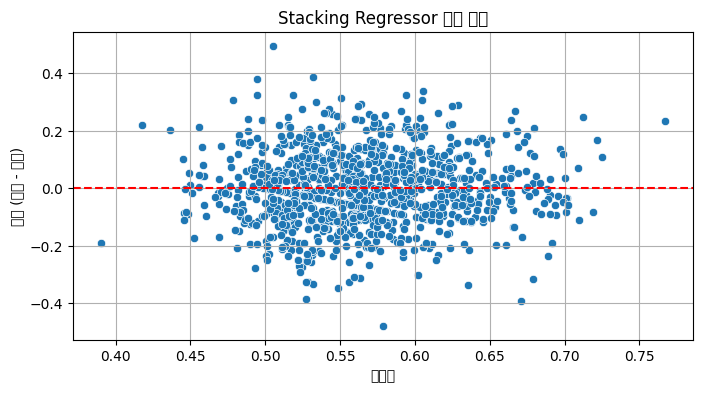

C:\Users\alsspp01\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\alsspp01\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\alsspp01\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\alsspp01\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\alsspp01\AppData\Local\Programs\Python\Python313\L

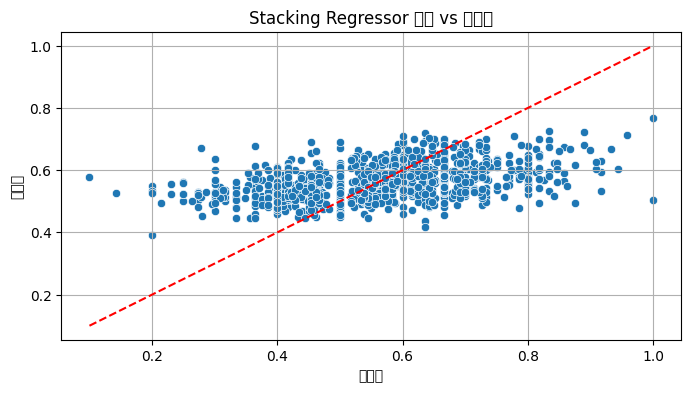

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

y_pred = stacking.predict(X_test)
residuals = y_test - y_pred

# 1. 잔차 플롯
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_pred, y=residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('예측값')
plt.ylabel('잔차 (실제 - 예측)')
plt.title('Stacking Regressor 잔차 플롯')
plt.grid(True)
plt.show()

# 2. 실제 vs 예측값 산점도
plt.figure(figsize=(8, 4))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel('실제값')
plt.ylabel('예측값')
plt.title('Stacking Regressor 예측 vs 실제값')
plt.grid(True)
plt.show()
